In [4]:
!pip install optuna lightgbm catboost xgboost scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (precision_recall_curve, roc_auc_score,
                                     average_precision_score, recall_score,
                                     precision_score, f1_score, confusion_matrix,
                                     ConfusionMatrixDisplay)
from sklearn.pipeline        import Pipeline

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/content/drive/MyDrive/final_pre-renewal_churn_dataset.csv')

In [6]:
print(f"Raw shape        : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"\nRenewal_Year distribution:")
print(df["Renewal_Year"].value_counts().sort_index())

Raw shape        : (112081, 60)
Columns          : ['Co_Ref', 'year_key', 'Renewal_Year', 'payment_timeframe_missing', 'Total_Renewal_Score_New', 'payment_unknown', 'Payment_Timeframe', 'Sustainability_Score', 'payment_is_bacs', 'Auto_Renewal_Score', 'Tenure_Scores', 'Current_World_Pay_Token', 'payment_is_card', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Discount_Amount', 'price_increase_pct', 'Gross', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Current_Anchorings', 'Last_Band', 'price_change', 'Anchoring_Score', 'Proforma_World_Pay_Token', 'Tenure_Years', '#_of_Connection', 'is_new_customer', 'Last_Connections', 'Tenure_Group', 'rc_desire_cancel_desired_to_cancel_true', 'crm_contractor_suggested_leave', 'Current_Auto_Renewal_Flag', 'crm_contractor_sentiment_score', 'Amount', 'PQQNet', 'had_rc_interaction', 'rc_Membership_Renewal_Decision', 'payment_is_worldpay', 'Band', 'had_em_interaction', 'Connection_Group', 'crm_agent_chase_count', 'crm_negative_customer_exper

In [7]:
#STEP 2 — TRAIN / TEST SPLIT (Time-Based)
TARGET     = "churn_label"
DROP_COLS  = ["Co_Ref", "year_key", "Renewal_Year"]

train_df = df[df["Renewal_Year"] <  2025].copy()
test_df  = df[df["Renewal_Year"] >= 2025].copy()

# Drop identifier + split columns
X_train = train_df.drop(columns=[TARGET] + DROP_COLS, errors="ignore")
X_test  = test_df.drop(columns=[TARGET]  + DROP_COLS, errors="ignore")
y_train = train_df[TARGET].astype(int)
y_test  = test_df[TARGET].astype(int)

print(f"Train shape      : {X_train.shape}  | Churn rate: {y_train.mean():.4f}")
print(f"Test  shape      : {X_test.shape}   | Churn rate: {y_test.mean():.4f}")
print(f"\nTrain class counts:\n{y_train.value_counts()}")
print(f"\nTest  class counts:\n{y_test.value_counts()}")

# Imbalance ratio — used for scale_pos_weight
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight : {SCALE_POS_WEIGHT:.2f}")


Train shape      : (67220, 56)  | Churn rate: 0.1138
Test  shape      : (44861, 56)   | Churn rate: 0.0970

Train class counts:
churn_label
0    59570
1     7650
Name: count, dtype: int64

Test  class counts:
churn_label
0    40509
1     4352
Name: count, dtype: int64

scale_pos_weight : 7.79


In [8]:
# STEP 3 — LABEL ENCODE CATEGORICALS

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Handle unseen labels in test gracefully
    X_test[col]  = X_test[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0]
        if x in le.classes_ else -1
    )
    label_encoders[col] = le

print(f"Encoded {len(cat_cols)} columns.")
print(f"Final feature count: {X_train.shape[1]}")

Categorical columns: ['Proforma_Membership_Status', 'Discount_Amount', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Last_Band', 'Tenure_Group', 'Band', 'Connection_Group', 'Anchor_Group']
Encoded 9 columns.
Final feature count: 56


In [9]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name,
                   threshold=0.5, verbose=True):
    """
    Train model, evaluate on test set.
    Returns dict of metrics.
    """
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= threshold).astype(int)

    pr_auc   = average_precision_score(y_te, probs)
    roc_auc  = roc_auc_score(y_te, probs)
    recall   = recall_score(y_te, preds)
    precision= precision_score(y_te, preds, zero_division=0)
    f2       = (5 * precision * recall) / (4 * precision + recall + 1e-8)

    if verbose:
        print(f"\n  {model_name}")
        print(f"  PR-AUC    : {pr_auc:.4f}   ← PRIMARY")
        print(f"  ROC-AUC   : {roc_auc:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  Precision : {precision:.4f}")
        print(f"  F2-Score  : {f2:.4f}")

    return {
        "model_name" : model_name,
        "model"      : model,
        "probs"      : probs,
        "pr_auc"     : pr_auc,
        "roc_auc"    : roc_auc,
        "recall"     : recall,
        "precision"  : precision,
        "f2"         : f2
    }


def f2_score(precision, recall):
    return (5 * precision * recall) / (4 * precision + recall + 1e-8)

In [12]:
from sklearn.impute import SimpleImputer
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

print("NaNs in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNaNs in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

if X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0:
    print("\nNo NaN values found in X_train and X_test after imputation. Proceeding with model training.")
else:
    print("\nWarning: NaN values still present after imputation. Please investigate.")

NaNs in X_train:
Series([], dtype: int64)

NaNs in X_test:
Series([], dtype: int64)

No NaN values found in X_train and X_test after imputation. Proceeding with model training.


In [25]:
final_drops = [
    "payment_timeframe_missing",       # perfect target copy
    "payment_unknown",                 # 100% churn post-outcome recording
    "crm_contractor_suggested_leave",  # zero variance in train set
    "crm_contractor_sentiment_score",  # zero variance in train set
]

X_train = X_train.drop(columns=final_drops, errors="ignore")
X_test  = X_test.drop(columns=final_drops, errors="ignore")

print(f"Features remaining: {X_train.shape[1]}")

Features remaining: 52


STAGE 1 — INDIVIDUAL MODELS

>>> Logistic Regression (Baseline)

  Logistic Regression
  PR-AUC    : 0.9879   ← PRIMARY
  ROC-AUC   : 0.9987
  Recall    : 0.9991
  Precision : 0.7422
  F2-Score  : 0.9344

>>> Random Forest

  Random Forest
  PR-AUC    : 0.9602   ← PRIMARY
  ROC-AUC   : 0.9925
  Recall    : 0.9432
  Precision : 0.5946
  F2-Score  : 0.8442

>>> XGBoost

  XGBoost
  PR-AUC    : 0.9912   ← PRIMARY
  ROC-AUC   : 0.9988
  Recall    : 0.9938
  Precision : 0.7323
  F2-Score  : 0.9276

>>> LightGBM

  LightGBM
  PR-AUC    : 0.9975   ← PRIMARY
  ROC-AUC   : 0.9997
  Recall    : 0.9979
  Precision : 0.7988
  F2-Score  : 0.9505

>>> CatBoost

  CatBoost
  PR-AUC    : 0.9876   ← PRIMARY
  ROC-AUC   : 0.9984
  Recall    : 0.9920
  Precision : 0.7769
  F2-Score  : 0.9399

STAGE 1 SUMMARY — Ranked by PR-AUC
              Model  PR-AUC  ROC-AUC  Recall  Precision     F2
           LightGBM  0.9975   0.9997  0.9979     0.7988 0.9505
            XGBoost  0.9912   0.9988  0.9938     0.732

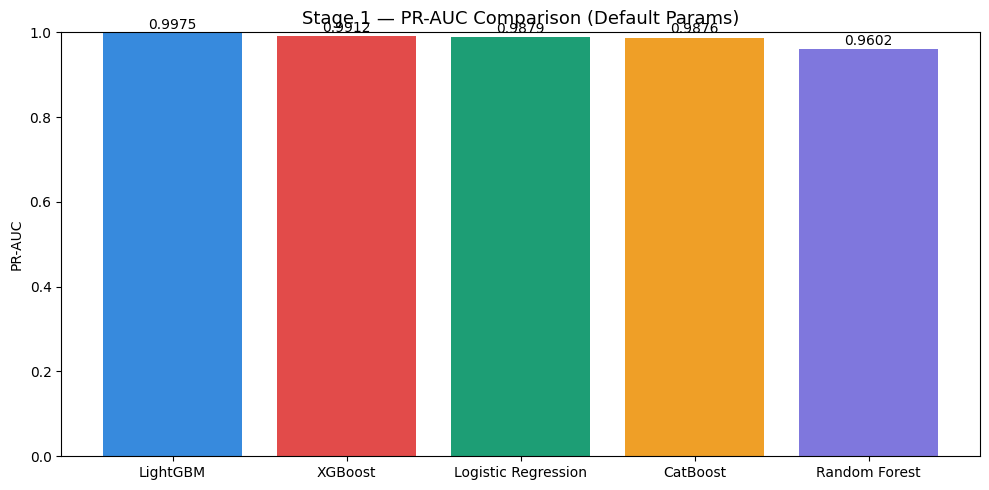

In [26]:
print("STAGE 1 — INDIVIDUAL MODELS")

stage1_results = []

# ── 1a. Logistic Regression (Baseline) ───────────────────────────────────────
print("\n>>> Logistic Regression (Baseline)")

# LR needs scaling — wrap in pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
res = evaluate_model(lr_pipeline, X_train, y_train,
                     X_test, y_test, "Logistic Regression")
stage1_results.append(res)

# ── 1b. Random Forest ─────────────────────────────────────────────────────────
print("\n>>> Random Forest")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
res = evaluate_model(rf, X_train, y_train,
                     X_test, y_test, "Random Forest")
stage1_results.append(res)

# ── 1c. XGBoost ───────────────────────────────────────────────────────────────
print("\n>>> XGBoost")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
res = evaluate_model(xgb, X_train, y_train,
                     X_test, y_test, "XGBoost")
stage1_results.append(res)

# ── 1d. LightGBM ──────────────────────────────────────────────────────────────
print("\n>>> LightGBM")

lgbm = LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res = evaluate_model(lgbm, X_train, y_train,
                     X_test, y_test, "LightGBM")
stage1_results.append(res)

# ── 1e. CatBoost ──────────────────────────────────────────────────────────────
print("\n>>> CatBoost")

cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols
                    if c in X_train.columns]

cb = CatBoostClassifier(
    iterations=300,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)
res = evaluate_model(cb, X_train, y_train,
                     X_test, y_test, "CatBoost")
stage1_results.append(res)

# ── Stage 1 Summary ───────────────────────────────────────────────────────────
stage1_df = pd.DataFrame([{
    "Model"    : r["model_name"],
    "PR-AUC"   : round(r["pr_auc"],   4),
    "ROC-AUC"  : round(r["roc_auc"],  4),
    "Recall"   : round(r["recall"],   4),
    "Precision": round(r["precision"],4),
    "F2"       : round(r["f2"],       4)
} for r in stage1_results]).sort_values("PR-AUC", ascending=False)

print("\n" + "=" * 60)
print("STAGE 1 SUMMARY — Ranked by PR-AUC")
print("=" * 60)
print(stage1_df.to_string(index=False))

# Pick top 2 for tuning
top2_names = stage1_df.head(2)["Model"].tolist()
print(f"\nTop 2 for tuning: {top2_names}")

# Stage 1 bar chart
plt.figure(figsize=(10, 5))
colors = ["#378ADD", "#E24B4A", "#1D9E75", "#EF9F27", "#7F77DD"]
bars = plt.bar(stage1_df["Model"], stage1_df["PR-AUC"], color=colors)
plt.title("Stage 1 — PR-AUC Comparison (Default Params)", fontsize=13)
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
for bar, val in zip(bars, stage1_df["PR-AUC"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01, f"{val:.4f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("stage1_comparison.png", dpi=150)
plt.show()

In [14]:
print(df["rc_Membership_Renewal_Decision"].value_counts())
print("\nChurn rate per value:")
print(df.groupby("rc_Membership_Renewal_Decision")["churn_label"].mean())

rc_Membership_Renewal_Decision
0.0    110127
1.0      1954
Name: count, dtype: int64

Churn rate per value:
rc_Membership_Renewal_Decision
0.0    0.097569
1.0    0.643296
Name: churn_label, dtype: float64


In [16]:
print("PROPER LEAKAGE CHECK")
print("=" * 60)

for col in X_train.columns:
    churn_rates = df.groupby(col)["churn_label"].mean()
    counts      = df.groupby(col)["churn_label"].count()

    # Only flag if:
    # 1. A value has 100% or 0% churn AND
    # 2. That value covers a significant portion of data (>5%) AND
    # 3. There are very few unique values (not a continuous column)

    n_unique     = df[col].nunique()
    total_rows   = len(df)

    for val, rate in churn_rates.items():
        group_size = counts[val]
        group_pct  = group_size / total_rows * 100

        if (rate == 1.0 or rate == 0.0) and group_pct > 5 and n_unique < 20:
            print(f"🚨 REAL LEAKAGE RISK: {col}")
            print(f"   Value={val} | Churn rate={rate:.2f} "
                  f"| Rows={group_size} ({group_pct:.1f}%)")
            break

PROPER LEAKAGE CHECK
🚨 REAL LEAKAGE RISK: payment_timeframe_missing
   Value=0 | Churn rate=0.00 | Rows=100079 (89.3%)
🚨 REAL LEAKAGE RISK: payment_unknown
   Value=1 | Churn rate=1.00 | Rows=7423 (6.6%)
🚨 REAL LEAKAGE RISK: payment_is_bacs
   Value=1 | Churn rate=0.00 | Rows=32810 (29.3%)


In [18]:
# Find which single feature perfectly separates classes
print("PERFECT SEPARATOR CHECK")
print("=" * 60)

for col in X_train.columns:
    # Check correlation with target
    if X_train[col].nunique() <= 50:
        rates = df.groupby(col)["churn_label"].mean()
        count_at_1 = df.groupby(col)["churn_label"].count() # Calculate counts here to ensure alignment

        if (rates == 1.0).any() and rates[rates == 1.0].index.tolist():
            for val in rates[rates == 1.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:   # more than 1% of data
                        print(f"🚨 {col} = {val} → 100% churn "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")
        if (rates == 0.0).any():
            for val in rates[rates == 0.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:
                        print(f"🚨 {col} = {val} → 0% churn  "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")

PERFECT SEPARATOR CHECK
🚨 payment_timeframe_missing = 1 → 100% churn | 12,002 rows (10.7%)
🚨 payment_timeframe_missing = 0 → 0% churn  | 100,079 rows (89.3%)
🚨 Total_Renewal_Score_New = 46.0 → 0% churn  | 3,639 rows (3.2%)
🚨 Total_Renewal_Score_New = 46.5 → 0% churn  | 4,501 rows (4.0%)
🚨 payment_unknown = 1 → 100% churn | 7,423 rows (6.6%)
🚨 payment_is_bacs = 1 → 0% churn  | 32,810 rows (29.3%)
🚨 payment_is_worldpay = 1 → 0% churn  | 1,682 rows (1.5%)


In [22]:
# Check what's left that's highly correlated
print("REMAINING HIGH CORRELATION CHECK")
print("=" * 60)

correlations = []
for col in X_train.columns:
    try:
        corr = abs(pd.to_numeric(X_train[col], errors='coerce')
                   .corr(y_train))
        correlations.append((col, round(corr, 4)))
    except:
        pass

correlations.sort(key=lambda x: x[1], reverse=True)
print(f"{'Feature':<60} {'|Correlation|'}")
print("-" * 70)
for col, corr in correlations[:20]:  # top 20
    print(f"{col:<60} {corr}")

REMAINING HIGH CORRELATION CHECK
Feature                                                      |Correlation|
----------------------------------------------------------------------
Total_Renewal_Score_New                                      0.6315
payment_unknown                                              0.6106
Tenure_Scores                                                0.4657
is_new_customer                                              0.3902
Discount_Amount                                              0.349
Renewal_Score_At_Release                                     0.3297
price_increase_pct                                           0.3123
Sustainability_Score                                         0.2894
Proforma_Membership_Status                                   0.2871
Auto_Renewal_Score                                           0.2478
Current_World_Pay_Token                                      0.2477
price_change                                                 0.2457
Anchor

In [24]:
print(X_train["crm_contractor_suggested_leave"].value_counts())
print(X_train["crm_contractor_sentiment_score"].value_counts())

crm_contractor_suggested_leave
0.0    67220
Name: count, dtype: int64
crm_contractor_sentiment_score
0.0    67220
Name: count, dtype: int64


In [27]:
# Check feature importance from LightGBM
# The leaking feature will show dominance
import lightgbm as lgb

lgbm_quick = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
lgbm_quick.fit(X_train, y_train)

importance = pd.Series(
    lgbm_quick.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("TOP 15 FEATURES BY IMPORTANCE")
print("=" * 50)
print(importance.head(15))

# Also check top feature's churn rate distribution
top_feature = importance.index[0]
print(f"\nTop feature: {top_feature}")
print(f"Value counts:\n{X_train[top_feature].value_counts().head(10)}")
print(f"\nChurn rate per value:")
temp = pd.concat([X_train[top_feature], y_train], axis=1)
print(temp.groupby(top_feature)["churn_label"].mean().head(10))

TOP 15 FEATURES BY IMPORTANCE
Tenure_Years                360
Tenure_Scores               324
Payment_Timeframe           309
Total_Renewal_Score_New     225
payment_is_card             162
Discount_Amount             135
Proforma_World_Pay_Token    130
Renewal_Score_At_Release    121
is_new_customer             119
Gross                       119
Amount                      105
Last_Band                    96
payment_is_bacs              94
payment_is_worldpay          79
price_increase_pct           70
dtype: int32

Top feature: Tenure_Years
Value counts:
Tenure_Years
1.0     10556
2.0      7987
3.0      6054
4.0      4800
5.0      4398
6.0      4098
7.0      3949
8.0      3797
9.0      3331
10.0     2686
Name: count, dtype: int64

Churn rate per value:
Tenure_Years
0.0    0.837838
1.0    0.214759
2.0    0.161512
3.0    0.155269
4.0    0.120208
5.0    0.090723
6.0    0.091508
7.0    0.086604
8.0    0.065315
9.0    0.064245
Name: churn_label, dtype: float64


In [28]:

# The real test — check train vs test performance gap
# If train >> test, it's overfitting
# If train ≈ test (both very high), the data itself is highly separable

from sklearn.metrics import average_precision_score

lgbm_check = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
lgbm_check.fit(X_train, y_train)

train_probs = lgbm_check.predict_proba(X_train)[:, 1]
test_probs  = lgbm_check.predict_proba(X_test)[:, 1]

train_prauc = average_precision_score(y_train, train_probs)
test_prauc  = average_precision_score(y_test,  test_probs)

print(f"Train PR-AUC : {train_prauc:.4f}")
print(f"Test  PR-AUC : {test_prauc:.4f}")
print(f"Gap          : {train_prauc - test_prauc:.4f}")

# Also check test set size and churn distribution
print(f"\nTest set shape      : {X_test.shape}")
print(f"Test churn count    : {y_test.sum()}")
print(f"Test churn rate     : {y_test.mean():.4f}")
print(f"Train churn count   : {y_train.sum()}")
print(f"Train churn rate    : {y_train.mean():.4f}")

Train PR-AUC : 0.9999
Test  PR-AUC : 0.9983
Gap          : 0.0016

Test set shape      : (44861, 52)
Test churn count    : 4352
Test churn rate     : 0.0970
Train churn count   : 7650
Train churn rate    : 0.1138


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 20

tuned_models   = {}
best_params_log = {}

# ── Tune XGBoost if in top 2 ──────────────────────────────────────────────────
if "XGBoost" in top2_names:
    print("\n>>> Tuning XGBoost...")

    def xgb_objective(trial):
        params = {
            "n_estimators"    : trial.suggest_int("n_estimators", 200, 600),
            "max_depth"       : trial.suggest_int("max_depth", 4, 10),
            "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 6.0, 12.0),
            "eval_metric"     : "aucpr",
            "random_state"    : 42,
            "verbosity"       : 0,
            "n_jobs"          : -1
        }
        model  = XGBClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    xgb_study = optuna.create_study(direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_xgb_params = xgb_study.best_params
    best_params_log["XGBoost"] = best_xgb_params
    print(f"\nBest XGBoost params : {best_xgb_params}")
    print(f"Best CV PR-AUC      : {xgb_study.best_value:.4f}")

    tuned_xgb = XGBClassifier(**best_xgb_params, random_state=42,
                               verbosity=0, n_jobs=-1)
    tuned_xgb.fit(X_train, y_train)
    tuned_models["XGBoost"] = tuned_xgb

# ── Tune LightGBM if in top 2 ─────────────────────────────────────────────────
if "LightGBM" in top2_names:
    print("\n>>> Tuning LightGBM...")

    def lgbm_objective(trial):
        params = {
            "n_estimators"     : trial.suggest_int("n_estimators", 200, 600),
            "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
            "max_depth"        : trial.suggest_int("max_depth", 4, 12),
            "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "feature_fraction" : trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction" : trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq"     : 1,
            "class_weight"     : "balanced",
            "random_state"     : 42,
            "verbose"          : -1,
            "n_jobs"           : -1
        }
        model  = LGBMClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    lgbm_study = optuna.create_study(direction="maximize")
    lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_lgbm_params = lgbm_study.best_params
    best_params_log["LightGBM"] = best_lgbm_params
    print(f"\nBest LightGBM params : {best_lgbm_params}")
    print(f"Best CV PR-AUC       : {lgbm_study.best_value:.4f}")

    tuned_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42,
                                 verbose=-1, n_jobs=-1)
    tuned_lgbm.fit(X_train, y_train)
    tuned_models["LightGBM"] = tuned_lgbm

# ── Tune CatBoost if in top 2 ─────────────────────────────────────────────────
if "CatBoost" in top2_names:
    print("\n>>> Tuning CatBoost...")

    def cb_objective(trial):
        params = {
            "iterations"      : trial.suggest_int("iterations", 200, 600),
            "depth"           : trial.suggest_int("depth", 4, 10),
            "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg"     : trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "auto_class_weights": "Balanced",
            "random_seed"     : 42,
            "verbose"         : 0
        }
        model  = CatBoostClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    cb_study = optuna.create_study(direction="maximize")
    cb_study.optimize(cb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_cb_params = cb_study.best_params
    best_params_log["CatBoost"] = best_cb_params
    print(f"\nBest CatBoost params : {best_cb_params}")
    print(f"Best CV PR-AUC       : {cb_study.best_value:.4f}")

    tuned_cb = CatBoostClassifier(**best_cb_params,
                                   random_seed=42, verbose=0)
    tuned_cb.fit(X_train, y_train)
    tuned_models["CatBoost"] = tuned_cb

# ── Stage 2 Evaluation ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STAGE 2 — TUNED MODEL EVALUATION")
print("=" * 60)

stage2_results = []
for name, model in tuned_models.items():
    probs     = model.predict_proba(X_test)[:, 1]
    preds     = (probs >= 0.5).astype(int)
    pr_auc    = average_precision_score(y_test, probs)
    roc_auc   = roc_auc_score(y_test, probs)
    recall    = recall_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    f2        = f2_score(precision, recall)
    print(f"\n  {name} (Tuned)")
    print(f"  PR-AUC    : {pr_auc:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  F2-Score  : {f2:.4f}")
    stage2_results.append({
        "model_name": f"{name} (Tuned)", "model": model,
        "probs": probs, "pr_auc": pr_auc, "roc_auc": roc_auc,
        "recall": recall, "precision": precision, "f2": f2
    })

best_individual = max(stage2_results, key=lambda x: x["pr_auc"])
print(f"\nBest individual after tuning: {best_individual['model_name']}"
      f" | PR-AUC: {best_individual['pr_auc']:.4f}")


>>> Tuning XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]


Best XGBoost params : {'n_estimators': 536, 'max_depth': 10, 'learning_rate': 0.01455291988241609, 'min_child_weight': 7, 'subsample': 0.8623357725952293, 'colsample_bytree': 0.6064965542170678, 'scale_pos_weight': 6.221054972644256}
Best CV PR-AUC      : 0.9988

>>> Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]


Best LightGBM params : {'n_estimators': 453, 'num_leaves': 150, 'max_depth': 9, 'learning_rate': 0.026014221302181072, 'min_child_samples': 36, 'feature_fraction': 0.6097140959960876, 'bagging_fraction': 0.9873697967799268}
Best CV PR-AUC       : 0.9990

STAGE 2 — TUNED MODEL EVALUATION

  XGBoost (Tuned)
  PR-AUC    : 0.9879
  ROC-AUC   : 0.9985
  Recall    : 0.9915
  Precision : 0.7871
  F2-Score  : 0.9426

  LightGBM (Tuned)
  PR-AUC    : 0.9960
  ROC-AUC   : 0.9995
  Recall    : 0.9926
  Precision : 0.8156
  F2-Score  : 0.9513

Best individual after tuning: LightGBM (Tuned) | PR-AUC: 0.9960


In [31]:
stage3_results = []

# Collect tuned models + RF for ensemble
ensemble_members = list(tuned_models.items())

# Always include RF as third diverse member for ensemble
rf_trained = [r["model"] for r in stage1_results
              if r["model_name"] == "Random Forest"][0]

# ── 3a. Voting Ensemble ───────────────────────────────────────────────────────
print("\n>>> Voting Ensemble (soft voting)")

voting_estimators = [(name, model) for name, model in ensemble_members]
voting_estimators.append(("RandomForest", rf_trained))

voting = VotingClassifier(
    estimators=voting_estimators,
    voting="soft"
)
voting.fit(X_train, y_train)

voting_probs  = voting.predict_proba(X_test)[:, 1]
voting_preds  = (voting_probs >= 0.5).astype(int)
v_pr_auc      = average_precision_score(y_test, voting_probs)
v_roc_auc     = roc_auc_score(y_test, voting_probs)
v_recall      = recall_score(y_test, voting_preds)
v_precision   = precision_score(y_test, voting_preds, zero_division=0)
v_f2          = f2_score(v_precision, v_recall)

print(f"  PR-AUC    : {v_pr_auc:.4f}")
print(f"  ROC-AUC   : {v_roc_auc:.4f}")
print(f"  Recall    : {v_recall:.4f}")
print(f"  Precision : {v_precision:.4f}")
print(f"  F2-Score  : {v_f2:.4f}")

stage3_results.append({
    "model_name": "Voting Ensemble", "model": voting,
    "probs": voting_probs, "pr_auc": v_pr_auc, "roc_auc": v_roc_auc,
    "recall": v_recall, "precision": v_precision, "f2": v_f2
})

# ── 3b. Stacking ──────────────────────────────────────────────────────────────
print("\n>>> Stacking Ensemble (LR meta learner)")

stacking_estimators = [(name, model) for name, model in ensemble_members]
stacking_estimators.append(("RandomForest", rf_trained))

# LR as meta learner — simple, avoids overfitting
meta_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1
)
stacking.fit(X_train, y_train)

stack_probs  = stacking.predict_proba(X_test)[:, 1]
stack_preds  = (stack_probs >= 0.5).astype(int)
s_pr_auc     = average_precision_score(y_test, stack_probs)
s_roc_auc    = roc_auc_score(y_test, stack_probs)
s_recall     = recall_score(y_test, stack_preds)
s_precision  = precision_score(y_test, stack_preds, zero_division=0)
s_f2         = f2_score(s_precision, s_recall)

print(f"  PR-AUC    : {s_pr_auc:.4f}")
print(f"  ROC-AUC   : {s_roc_auc:.4f}")
print(f"  Recall    : {s_recall:.4f}")
print(f"  Precision : {s_precision:.4f}")
print(f"  F2-Score  : {s_f2:.4f}")

stage3_results.append({
    "model_name": "Stacking Ensemble", "model": stacking,
    "probs": stack_probs, "pr_auc": s_pr_auc, "roc_auc": s_roc_auc,
    "recall": s_recall, "precision": s_precision, "f2": s_f2
})


>>> Voting Ensemble (soft voting)
  PR-AUC    : 0.9887
  ROC-AUC   : 0.9985
  Recall    : 0.9885
  Precision : 0.8168
  F2-Score  : 0.9486

>>> Stacking Ensemble (LR meta learner)
  PR-AUC    : 0.9907
  ROC-AUC   : 0.9988
  Recall    : 0.9915
  Precision : 0.8119
  F2-Score  : 0.9495


In [33]:
all_results = stage2_results + stage3_results
all_df = pd.DataFrame([{
    "Model"    : r["model_name"],
    "PR-AUC"   : round(r["pr_auc"],   4),
    "ROC-AUC"  : round(r["roc_auc"],  4),
    "Recall"   : round(r["recall"],   4),
    "Precision": round(r["precision"],4),
    "F2"       : round(r["f2"],       4)
} for r in all_results]).sort_values("PR-AUC", ascending=False)

print("\nAll models ranked by PR-AUC:")
print(all_df.to_string(index=False))


winner = max(all_results, key=lambda x: x["pr_auc"])
FINAL_MODEL  = winner["model"]
FINAL_PROBS  = winner["probs"]
FINAL_NAME   = winner["model_name"]

print(f"\n FINAL MODEL SELECTED : {FINAL_NAME}")
print(f"   PR-AUC               : {winner['pr_auc']:.4f}")



All models ranked by PR-AUC:
            Model  PR-AUC  ROC-AUC  Recall  Precision     F2
 LightGBM (Tuned)  0.9960   0.9995  0.9926     0.8156 0.9513
Stacking Ensemble  0.9907   0.9988  0.9915     0.8119 0.9495
  Voting Ensemble  0.9887   0.9985  0.9885     0.8168 0.9486
  XGBoost (Tuned)  0.9879   0.9985  0.9915     0.7871 0.9426

 FINAL MODEL SELECTED : LightGBM (Tuned)
   PR-AUC               : 0.9960


In [34]:
cv_single = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in cv_single.split(X_train, y_train):
    X_val_thr = X_train.iloc[val_idx]
    y_val_thr = y_train.iloc[val_idx]

FINAL_MODEL.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
val_probs = FINAL_MODEL.predict_proba(X_val_thr)[:, 1]

# Retrain on full train after threshold is found
FINAL_MODEL.fit(X_train, y_train)

thresholds   = np.arange(0.1, 0.9, 0.01)
f2_scores_thr = []

for thr in thresholds:
    preds_thr  = (val_probs >= thr).astype(int)
    prec       = precision_score(y_val_thr, preds_thr, zero_division=0)
    rec        = recall_score(y_val_thr, preds_thr)
    f2_scores_thr.append(f2_score(prec, rec))

best_idx       = np.argmax(f2_scores_thr)
BEST_THRESHOLD = thresholds[best_idx]
best_f2_thr    = f2_scores_thr[best_idx]

print(f"Optimal threshold : {BEST_THRESHOLD:.2f}")
print(f"F2-Score at threshold: {best_f2_thr:.4f}")


Optimal threshold : 0.23
F2-Score at threshold: 0.9954



  Model             : LightGBM (Tuned)
  Threshold         : 0.23
  ─────────────────────────────
  PR-AUC    : 0.9960   ← PRIMARY
  ROC-AUC   : 0.9995
  Recall    : 0.9968
  Precision : 0.7415
  F2-Score  : 0.9326


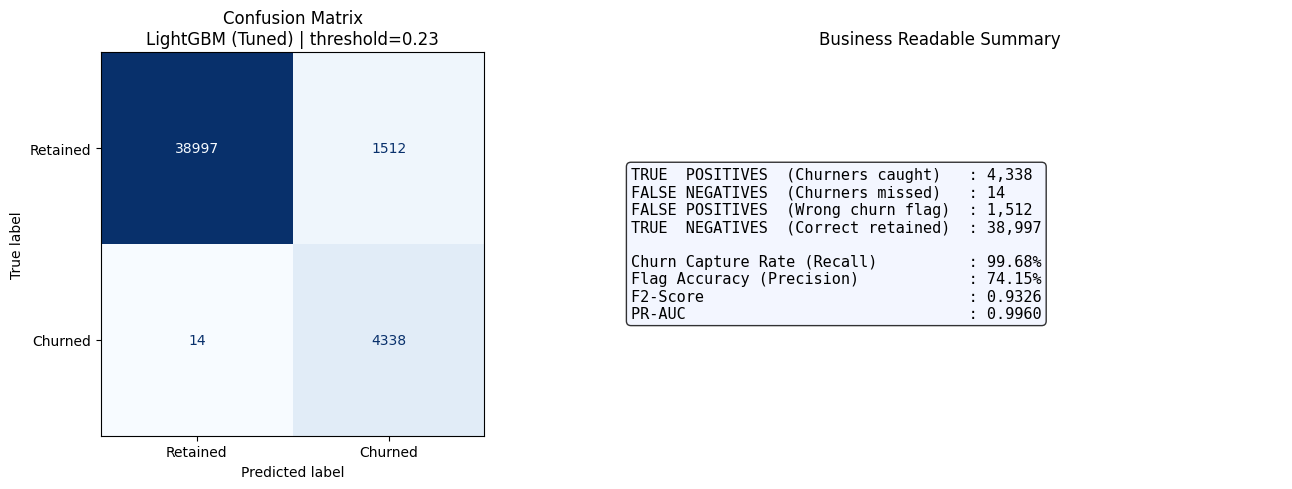

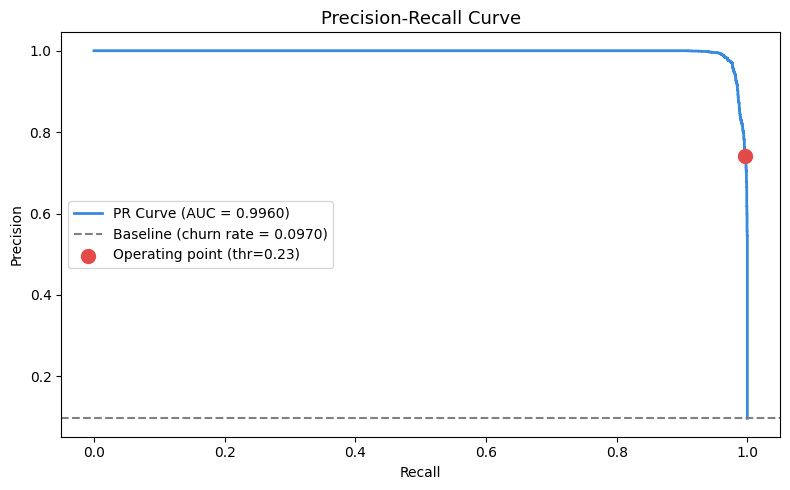

In [35]:
final_probs = FINAL_MODEL.predict_proba(X_test)[:, 1]
final_preds = (final_probs >= BEST_THRESHOLD).astype(int)

final_pr_auc   = average_precision_score(y_test, final_probs)
final_roc_auc  = roc_auc_score(y_test, final_probs)
final_recall   = recall_score(y_test, final_preds)
final_precision= precision_score(y_test, final_preds, zero_division=0)
final_f2       = f2_score(final_precision, final_recall)

print(f"\n  Model             : {FINAL_NAME}")
print(f"  Threshold         : {BEST_THRESHOLD:.2f}")
print(f"  ─────────────────────────────")
print(f"  PR-AUC    : {final_pr_auc:.4f}   ← PRIMARY")
print(f"  ROC-AUC   : {final_roc_auc:.4f}")
print(f"  Recall    : {final_recall:.4f}")
print(f"  Precision : {final_precision:.4f}")
print(f"  F2-Score  : {final_f2:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, final_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Retained", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix\n{FINAL_NAME} | threshold={BEST_THRESHOLD:.2f}")

tn, fp, fn, tp = cm.ravel()
axes[1].axis("off")
summary_text = (
    f"TRUE  POSITIVES  (Churners caught)   : {tp:,}\n"
    f"FALSE NEGATIVES  (Churners missed)   : {fn:,}\n"
    f"FALSE POSITIVES  (Wrong churn flag)  : {fp:,}\n"
    f"TRUE  NEGATIVES  (Correct retained)  : {tn:,}\n\n"
    f"Churn Capture Rate (Recall)          : {final_recall:.2%}\n"
    f"Flag Accuracy (Precision)            : {final_precision:.2%}\n"
    f"F2-Score                             : {final_f2:.4f}\n"
    f"PR-AUC                               : {final_pr_auc:.4f}"
)
axes[1].text(0.05, 0.5, summary_text,
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="center",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f0f4ff", alpha=0.8))
axes[1].set_title("Business Readable Summary")

plt.tight_layout()
plt.savefig("final_evaluation.png", dpi=150)
plt.show()

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision_curve, recall_curve, _ = precision_recall_curve(y_test, final_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color="#378ADD", linewidth=2,
         label=f"PR Curve (AUC = {final_pr_auc:.4f})")
plt.axhline(y=y_test.mean(), color="gray", linestyle="--",
            label=f"Baseline (churn rate = {y_test.mean():.4f})")
plt.scatter([final_recall], [final_precision], color="#E24B4A",
            s=100, zorder=5,
            label=f"Operating point (thr={BEST_THRESHOLD:.2f})")
plt.title("Precision-Recall Curve", fontsize=13)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()

In [36]:
print(f"  Final model       : {FINAL_NAME}")
print(f"  Decision threshold: {BEST_THRESHOLD:.2f}")
print(f"  Test period       : 2025 renewals")
print(f"  PR-AUC            : {final_pr_auc:.4f}")
print(f"  Recall            : {final_recall:.4f}")
print(f"  Precision         : {final_precision:.4f}")
print(f"  F2-Score          : {final_f2:.4f}")
print(f"  ROC-AUC           : {final_roc_auc:.4f}")
print(f"\nBest hyperparameters found:")
for model_name, params in best_params_log.items():
    print(f"\n  {model_name}:")
    for k, v in params.items():
        print(f"    {k:25} : {v}")
print("\n✅ Model ready for explainability phase (SHAP)")

  Final model       : LightGBM (Tuned)
  Decision threshold: 0.23
  Test period       : 2025 renewals
  PR-AUC            : 0.9960
  Recall            : 0.9968
  Precision         : 0.7415
  F2-Score          : 0.9326
  ROC-AUC           : 0.9995

Best hyperparameters found:

  XGBoost:
    n_estimators              : 536
    max_depth                 : 10
    learning_rate             : 0.01455291988241609
    min_child_weight          : 7
    subsample                 : 0.8623357725952293
    colsample_bytree          : 0.6064965542170678
    scale_pos_weight          : 6.221054972644256

  LightGBM:
    n_estimators              : 453
    num_leaves                : 150
    max_depth                 : 9
    learning_rate             : 0.026014221302181072
    min_child_samples         : 36
    feature_fraction          : 0.6097140959960876
    bagging_fraction          : 0.9873697967799268

✅ Model ready for explainability phase (SHAP)
